# **Diamond Price Prediction**

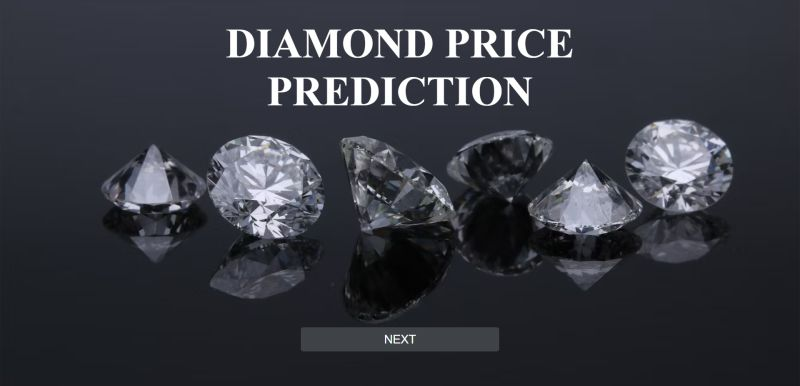

**importing the libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

# importing the dataset

In [3]:
dia=pd.read_csv("diamonds.csv")

price price in US dollars ($326--$18,823)This is the target column containing tags for the features.

30,000 to 15,00,000 ( 3ok to 15 lakhs rupees)

The 4 Cs of Diamonds:-

carat (0.2--5.01) The carat is the diamond’s physical weight measured in metric carats.  One carat equals 1/5 gram and is subdivided into 100 points. Carat weight is the most objective grade of the 4Cs.


cut (Fair, Good, Very Good, Premium, Ideal) In determining the quality of the cut, the diamond grader evaluates the cutter’s skill in the fashioning of the diamond. The more precise the diamond is cut, the more captivating the diamond is to the eye.  


color, from J (worst) to D (best) The colour of gem-quality diamonds occurs in many hues. In the range from colourless to light yellow or light brown. Colourless diamonds are the rarest. Other natural colours (blue, red, pink for example) are known as "fancy,” and their colour grading is different than from white colorless diamonds.  


clarity (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)) Diamonds can have internal characteristics known as inclusions or external characteristics known as blemishes. Diamonds without inclusions or blemishes are rare; however, most characteristics can only be seen with magnification.  

Dimensions

x length in mm (0--10.74)

y width in mm (0--58.9)

z depth in mm (0--31.8)

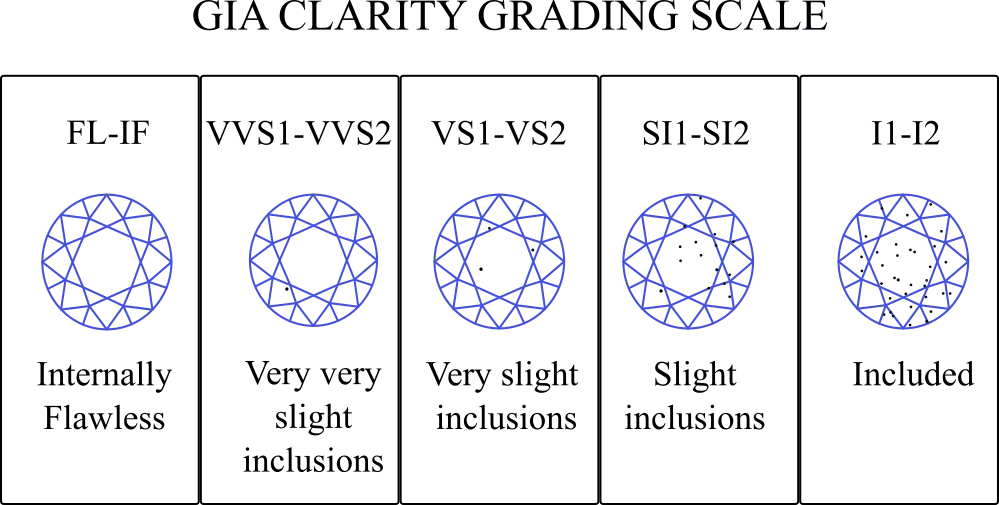

In [4]:
dia.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
dia.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
dia.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
dia=dia.drop(['Unnamed: 0'],axis=1)

In [9]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
dia.shape

(53940, 10)

# Data visualization

In [12]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='cut', ylabel='count'>

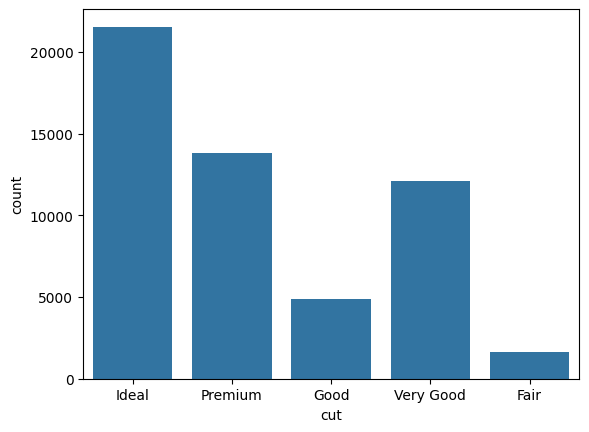

In [13]:
sns.countplot(data=dia,x='cut')

<Axes: xlabel='color', ylabel='count'>

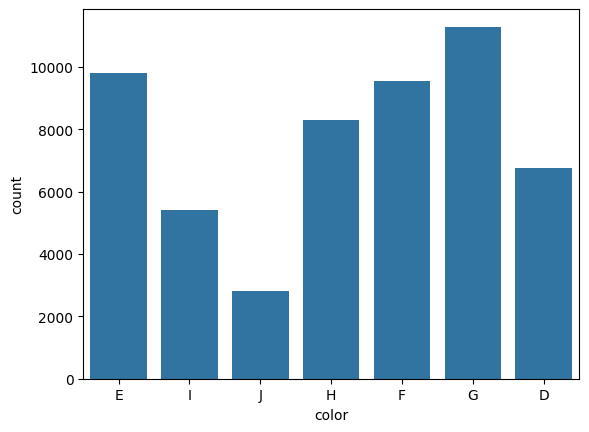

In [14]:
sns.countplot(data=dia,x='color')

<Axes: >

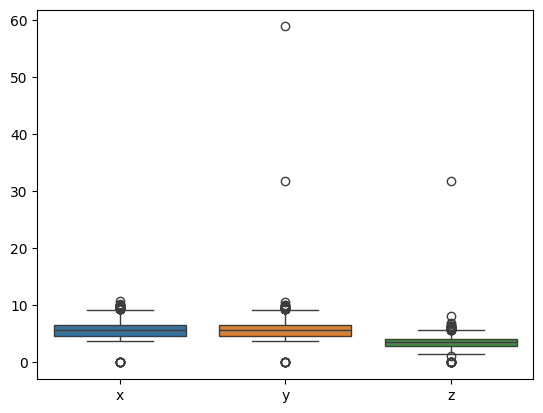

In [15]:
sns.boxplot(data=dia[['x','y','z']])

<Axes: ylabel='count'>

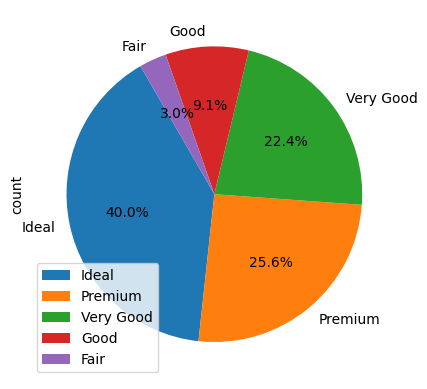

In [16]:
dia['cut'].value_counts().plot(kind='pie',autopct='%2.1f%%',legend=True,startangle=120)

Text(0, 0.5, 'number of diamonds')

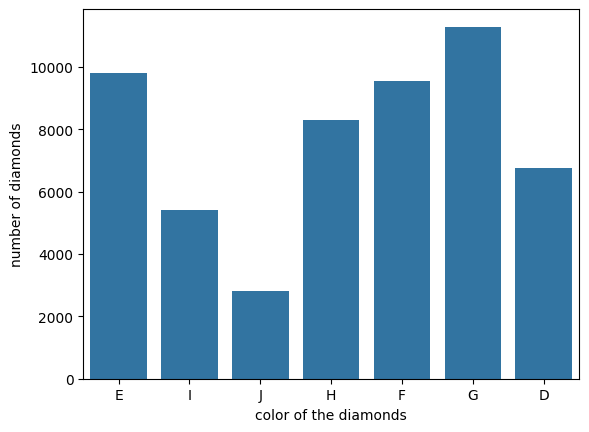

In [17]:
sns.countplot(data=dia,x='color')
plt.xlabel("color of the diamonds")
plt.ylabel('number of diamonds')

<Axes: xlabel='clarity', ylabel='count'>

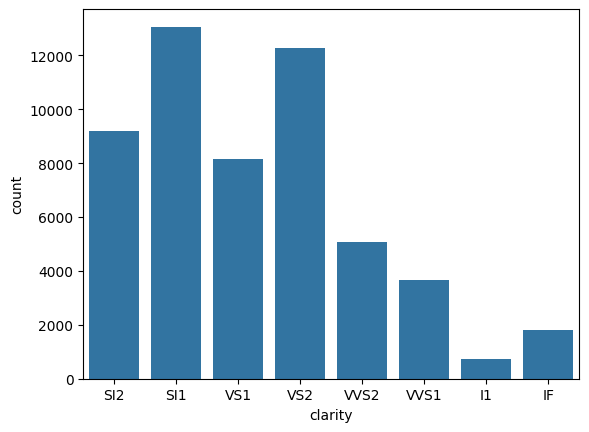

In [18]:
sns.countplot(data=dia,x='clarity')

what is the price of the cut?

Text(0.5, 1.0, 'prices of the cut of diamond')

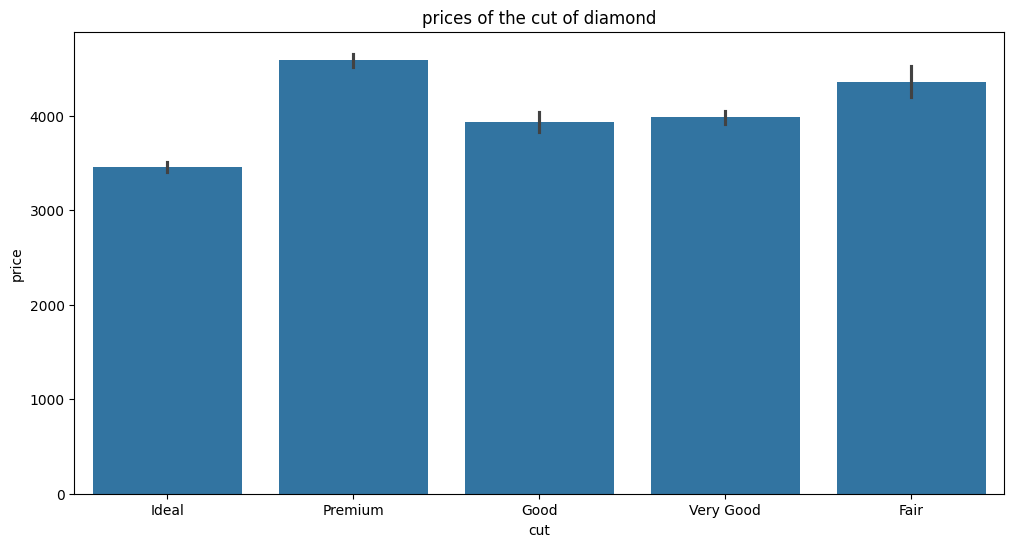

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(data=dia,x='cut',y='price')
plt.title('prices of the cut of diamond')

Text(0.5, 1.0, 'prices of the cut of diamond')

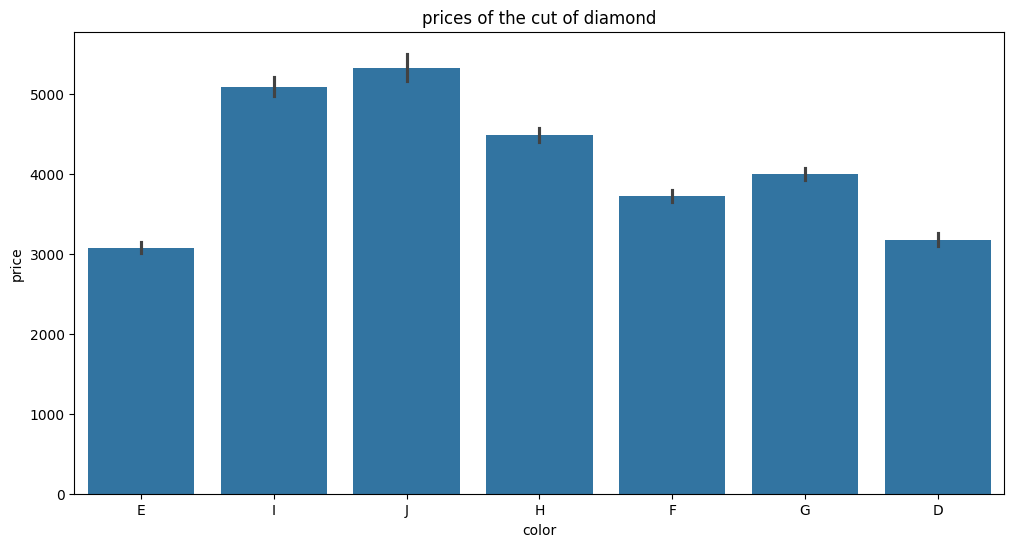

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(data=dia,x='color',y='price')
plt.title('prices of the cut of diamond')

Text(0.5, 1.0, 'prices of the cut of diamond')

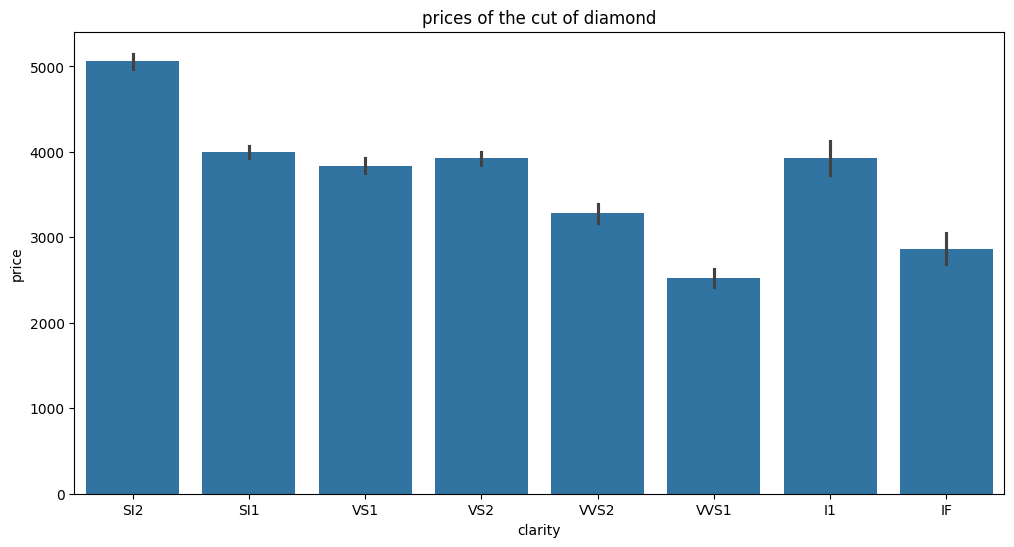

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(data=dia,x='clarity',y='price')
plt.title('prices of the cut of diamond')

Text(0.5, 1.0, 'color - cut - price  of diamond')

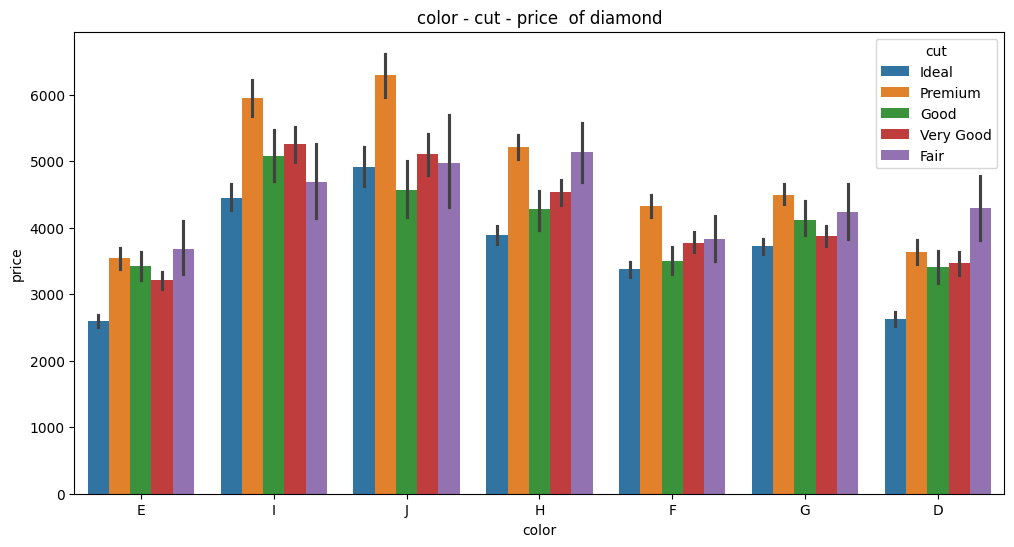

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(data=dia,x='color',y='price',hue='cut')
plt.title('color - cut - price  of diamond')

Text(0.5, 1.0, 'cut - price - clarity of diamond')

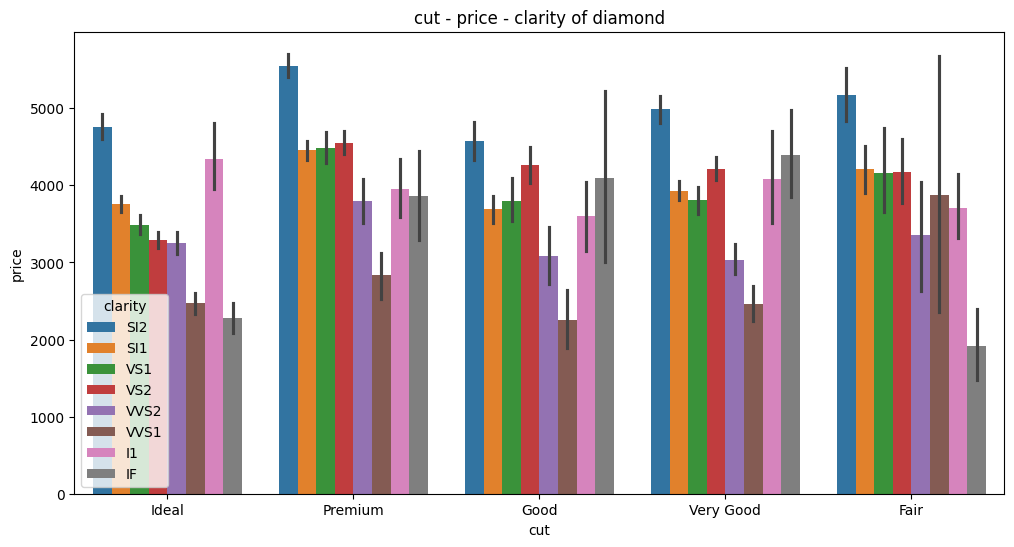

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(data=dia,x='cut',y='price',hue='clarity')
plt.title('cut - price - clarity of diamond')

# Data preprocessing

Data encoding to the machine learning

In [24]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [25]:
dia['cut']=dia['cut'].map({'Ideal':0,'Premium':1,'Very Good':2,'Good':3,'Fair':4})

In [26]:
dia['color']=dia['color'].map({'G':0,'E':1,'F':2,'H':3,'D':4,'I':5,'J':6})

In [27]:
dia['clarity']=dia['clarity'].map({'SI1':0,'VS2':1,'SI2':2,'VS1':3,'VVS2':4,'VVS1':5,'IF':6,'I1':7})

In [28]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,1,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,2,63.3,58.0,335,4.34,4.35,2.75


converted all the categorical values into the numerical values according to the machine learning encoding

# Train Test Splitting the dataset

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x=dia.drop(['price'],axis=1)

In [31]:
y=dia['price']

In [32]:
x.shape,y.shape

((53940, 9), (53940,))

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

# Model Selection and training

# Decision Tree algorithm

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report ,roc_auc_score,confusion_matrix,roc_curve

In [33]:
DTR=DecisionTreeRegressor()
DTR

DecisionTreeRegressor()

In [34]:
DTR.fit(x_train,y_train)

DecisionTreeRegressor()

In [35]:
DTR.score(x_test,y_test)

0.9646758423786881

In [36]:
DTR.score(x_train,y_train)

0.9999948113472171

In [37]:
yhat=DTR.predict(x_test)
a=yhat.mean()
a

3941.292130144605

Text(0.5, 1.0, 'Actual vs fitted values in the dataset')

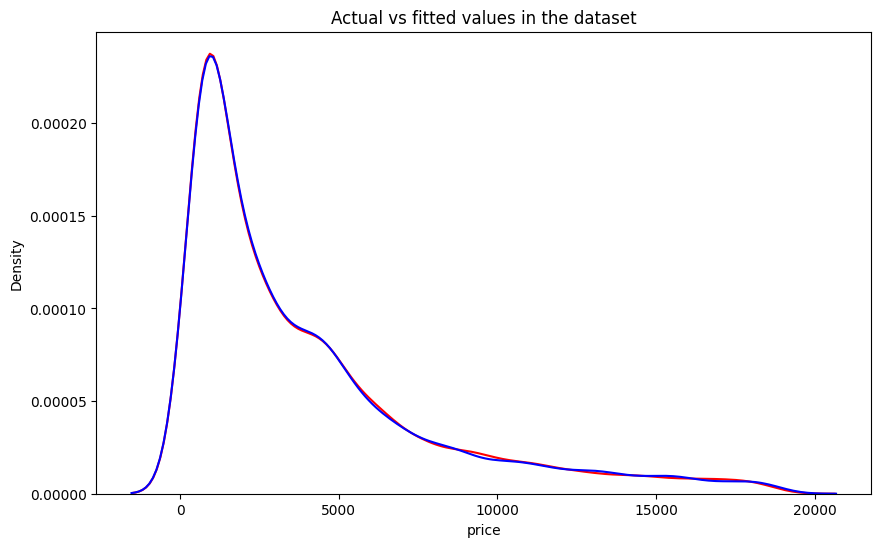

In [38]:
plt.figure(figsize=(10,6))
sns.distplot(y_test,color='r',hist=False,label='Actual values')
sns.distplot(yhat,color='b',hist=False,label='Fitted values')
plt.title("Actual vs fitted values in the dataset")

# Random forest algorithm

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

In [40]:
rf=RandomForestRegressor()
rf

RandomForestRegressor()

In [41]:
rf.fit(x_train,y_train)

RandomForestRegressor()

In [42]:
rf.score(x_train,y_train)

0.997313297838713

In [43]:
rf.score(x_test,y_test)

0.9808592370699044

In [44]:
yhat_rf=rf.predict(x_test)
b=yhat_rf.mean()
b

3945.4532330455354

<Axes: xlabel='price', ylabel='Density'>

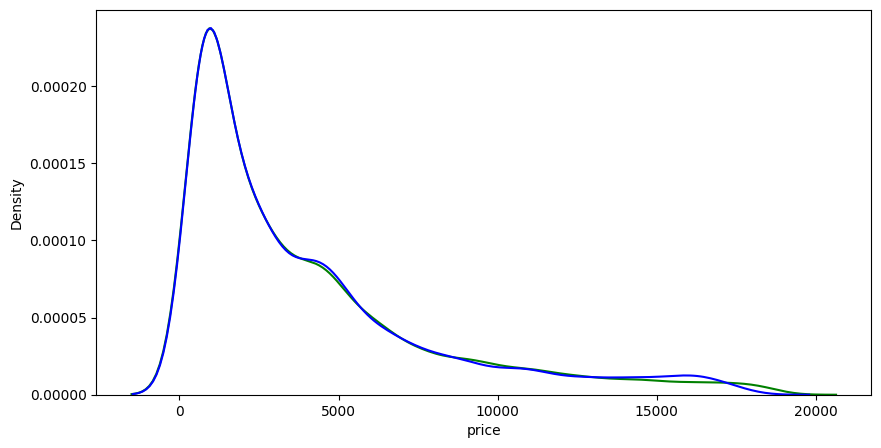

In [45]:
plt.figure(figsize=(10,5))
sns.distplot(y_test,hist=False,color='g')
sns.distplot(yhat_rf,hist=False,color='b')

In [46]:
price1=[]
for i in dia['price']:
    if i<5000:
        price1.append('least')
    elif (i>5001 & i<10000):
        price1.append('min')
    elif (i>10001 & i<15000):
        price1.append('medium')
    else:
        price1.append('max')
print(price1)

['least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 'least', 

# K nearest Neighbours

In [47]:
from sklearn.neighbors import KNeighborsClassifier

In [48]:
k = 5
knn_classifier = KNeighborsClassifier(n_neighbors=k)

In [49]:
knn_classifier.fit(x_train,y_train)

KNeighborsClassifier()

In [50]:
knn_classifier.score(x_train,y_train)

0.20012977382276603

In [51]:
knn_classifier.score(x_test,y_test)

0.023451983685576567

In [52]:
yhat_knn=knn_classifier.predict(x_test)
c=yhat_knn.mean()
c

3081.6150352243235

<Axes: xlabel='price', ylabel='Density'>

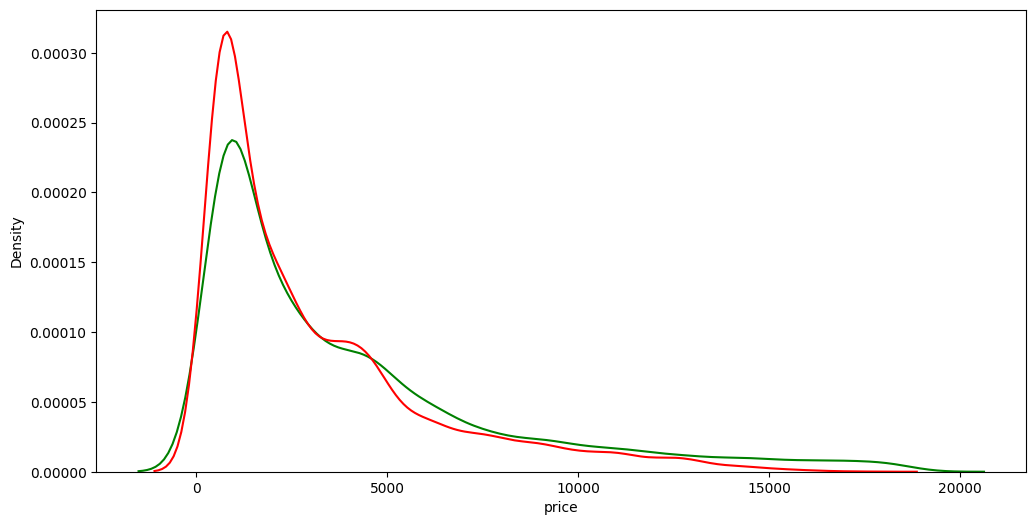

In [53]:
plt.figure(figsize=(12,6))
sns.distplot(y_test,hist=False,color='g')
sns.distplot(yhat_knn,hist=False,color='r')

**LINEAR REGRESSION MODEL**

In [54]:
from sklearn.linear_model import LinearRegression

In [55]:
lr1=LinearRegression()
lr1

LinearRegression()

In [56]:
lr1.fit(x_train,y_train)

LinearRegression()

In [57]:
lr1.score(x_train,y_train)

0.8698060950121344

In [58]:
lr1.score(x_test,y_test)

0.8704434099995932

In [59]:
yhlr=lr1.predict(x_test)
d=yhlr.mean()
d

3950.3619654934023

<Axes: xlabel='price', ylabel='Density'>

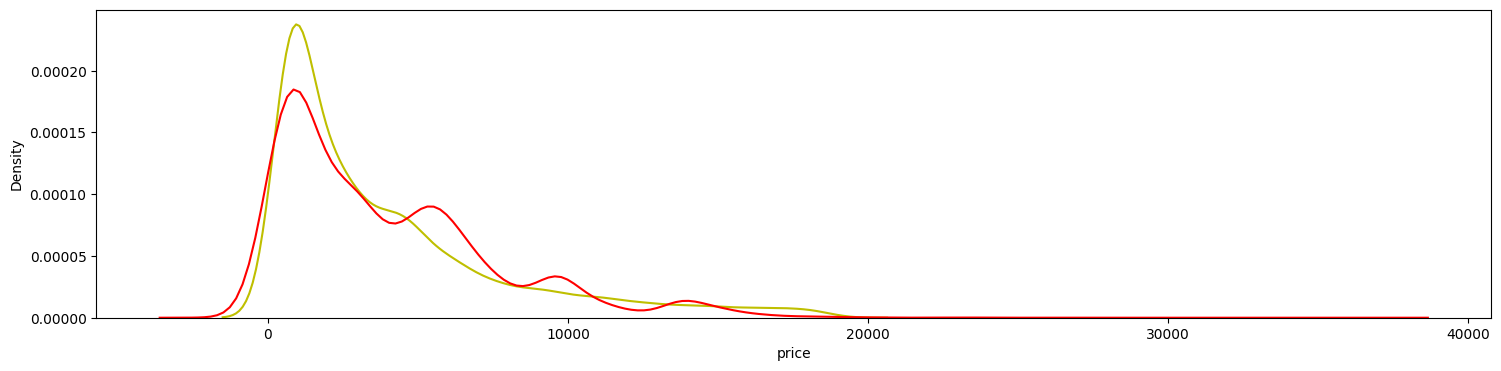

In [60]:
plt.figure(figsize=(18,4))
sns.distplot(y_test,hist=False,color='y')
sns.distplot(yhlr,hist=False,color='r')

# Model accuracy comparisons

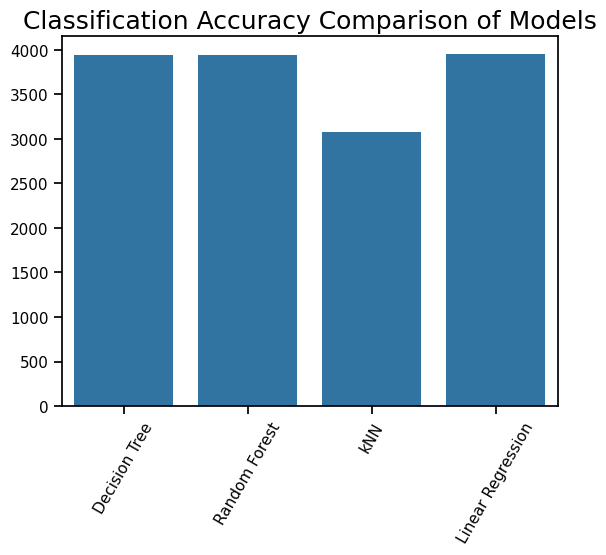

In [61]:
sns.set(context='notebook', style=None, palette='tab10')
models = ['Decision Tree', 'Random Forest', 'kNN','Linear Regression']
scores = [a,b,c,d]
ax = sns.barplot(x=models, y=scores)
ax.set_title('Classification Accuracy Comparison of Models', fontsize=18)
for item in ax.get_xticklabels():
    item.set_rotation(60)

In [62]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,1,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,2,63.3,58.0,335,4.34,4.35,2.75


# Prediction 1

In [63]:
input_data=[0.23,3,1,3,56.9,65.0,4.05,4.07,2.31]
inp_array=np.asarray(input_data)
inp_array
inp_rshape=inp_array.reshape(1,-1)
inp_rshape
prediction1 = DTR.predict(inp_rshape)
print("The pridicted Price for the above test data of Diamond is", prediction1, "Dollars")


The pridicted Price for the above test data of Diamond is [327.] Dollars


# Prediction 2

In [64]:
input_data1=[0.36,2,0,1,55.6,62.2,3.89,4.01,2.99]
inp_arr=np.asarray(input_data)
inp_rshap=inp_arr.reshape(1,-1)
prediction2=rf.predict(inp_rshap)

print("The pridicted Price for the above test data of Diamond is", prediction2, "Dollars")

The pridicted Price for the above test data of Diamond is [342.52] Dollars


In [65]:
import pickle

filename = 'Diamond_Price.pkl'
pickle.dump(rf,open(filename,'wb'))

# **True friends are like diamonds, precious and rare. False friends are like leaves, found everywhere.**